# Ejercicio 2: Análisis del access.log y detección de anomalias


Esta libreta analiza el registro de accesos `access.log` del frontend web. Deben **adjuntar el archivo `access.log`** en el mismo
directorio de esta libreta antes de ejecutar. El código asume ese nombre exacto.

In [ ]:
# Instalación de dependencias (en Binder puede tardar la primera vez)
import sys, subprocess
for pkg in ["pandas", "matplotlib", "adtk"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dependencias listas")

Dependencias listas


## 1. Cargar el access.log

In [2]:
import re
import pandas as pd

PATRON = re.compile(
    r'(?P<ip>\S+) \S+ \S+ \[(?P<fecha>[^\]]+)\] '
    r'"(?P<metodo>\S+) (?P<ruta>\S+) [^"]*" '
    r'(?P<status>\d{3}) (?P<bytes>\d+) "[^"]*" "(?P<ua>[^"]*)"'
)

filas = []
with open("access.log", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        m = PATRON.search(linea)
        if m:
            filas.append(m.groupdict())

df = pd.DataFrame(filas)
df["ts"] = pd.to_datetime(df["fecha"], format="%d/%b/%Y:%H:%M:%S %z")
df["status"] = df["status"].astype(int)
df["bytes"] = df["bytes"].astype(int)
df = df.set_index("ts").sort_index()
print("Registros cargados:", len(df))
df.head()

Registros cargados: 11387


,ip,fecha,metodo,ruta,status,bytes,ua
ts,,,,,,,
2026-03-10 02:00:00+00:00,190.10.46.103,10/Mar/2026:02:00:00 +0000,GET,/productos,200,1800,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
2026-03-10 02:00:00+00:00,190.10.17.213,10/Mar/2026:02:00:00 +0000,GET,/productos,200,3360,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...
2026-03-10 02:00:01+00:00,190.10.245.132,10/Mar/2026:02:00:01 +0000,GET,/api/v1/pagos/metodos,200,467,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...
2026-03-10 02:00:01+00:00,190.10.254.207,10/Mar/2026:02:00:01 +0000,GET,/static/js/app.js,200,4284,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...
2026-03-10 02:00:04+00:00,190.10.59.109,10/Mar/2026:02:00:04 +0000,GET,/,200,2390,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...


## 2. Serie de solicitudes por minuto
Primero observamos la forma global del tráfico.

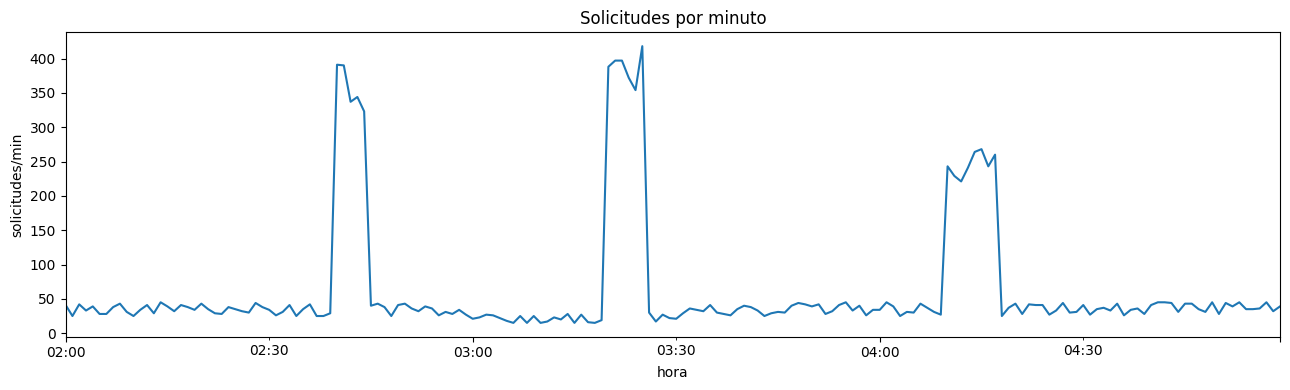

In [3]:
import matplotlib.pyplot as plt

por_minuto = df["ip"].resample("1min").count().rename("solicitudes")
plt.figure(figsize=(13,4))
por_minuto.plot()
plt.title("Solicitudes por minuto")
plt.ylabel("solicitudes/min"); plt.xlabel("hora")
plt.tight_layout(); plt.show()

## 3. Detección automática de picos

El detector compara cada punto contra su historia reciente (ventana `window`) y
lo marca como anómalo cuando se aleja mas de `c` veces la dispersion normal.
Es la misma idea de `PersistAD` de ADTK que vieron en clase.

Metodo de deteccion: ADTK PersistAD


/Users/william/Library/Mobile Documents/com~apple~CloudDocs/Cenfotec/MAESTRIA CIBERSEGURIDAD SERGURIDAD INFORMACION/CIB-209/SEM8/Practica/files/.venv/lib/python3.9/site-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/Users/william/Library/Mobile Documents/com~apple~CloudDocs/Cenfotec/MAESTRIA CIBERSEGURIDAD SERGURIDAD INFORMACION/CIB-209/SEM8/Practica/files/.venv/lib/python3.9/site-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/Users/william/Library/Mobile Documents/com~apple~CloudDocs/Cenfotec/MAE

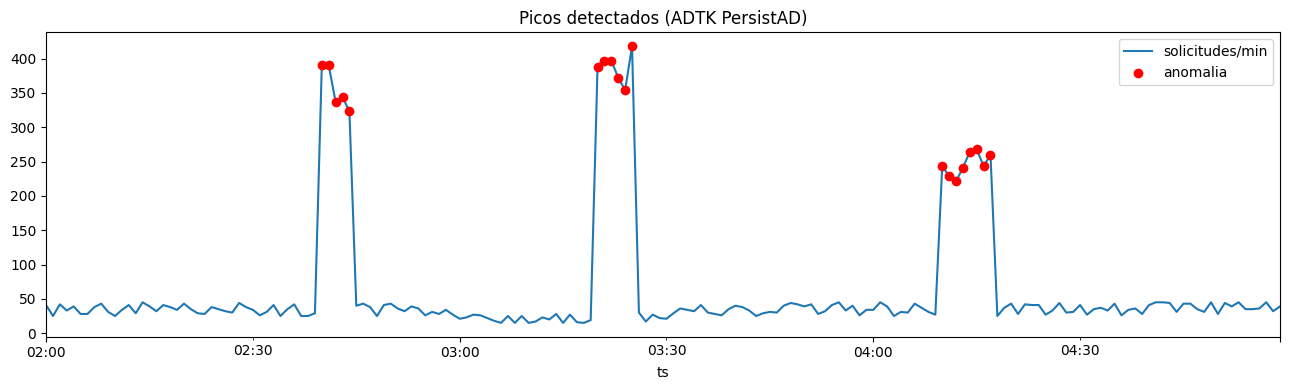

Minutos marcados como anomalos:
   2026-03-10 02:40:00+00:00 -> 391 solicitudes
   2026-03-10 02:41:00+00:00 -> 390 solicitudes
   2026-03-10 02:42:00+00:00 -> 337 solicitudes
   2026-03-10 02:43:00+00:00 -> 344 solicitudes
   2026-03-10 02:44:00+00:00 -> 323 solicitudes
   2026-03-10 03:20:00+00:00 -> 388 solicitudes
   2026-03-10 03:21:00+00:00 -> 397 solicitudes
   2026-03-10 03:22:00+00:00 -> 397 solicitudes
   2026-03-10 03:23:00+00:00 -> 372 solicitudes
   2026-03-10 03:24:00+00:00 -> 354 solicitudes
   2026-03-10 03:25:00+00:00 -> 418 solicitudes
   2026-03-10 04:10:00+00:00 -> 243 solicitudes
   2026-03-10 04:11:00+00:00 -> 229 solicitudes
   2026-03-10 04:12:00+00:00 -> 221 solicitudes
   2026-03-10 04:13:00+00:00 -> 241 solicitudes
   2026-03-10 04:14:00+00:00 -> 264 solicitudes
   2026-03-10 04:15:00+00:00 -> 268 solicitudes
   2026-03-10 04:16:00+00:00 -> 243 solicitudes
   2026-03-10 04:17:00+00:00 -> 260 solicitudes


In [ ]:
import numpy as np

# Parametros del detector. window es la ventana de historia reciente y
# c controla que tan lejos de lo normal debe estar un punto para ser anomalía.
window = 15
c = 3.0

def detectar(serie, window, c):
    """Detector tipo PersistAD. Intenta usar la libreria ADTK; si el entorno
    trae una version de pandas incompatible, usa una implementacion equivalente
    con los mismos parametros window y c."""
    try:
        from adtk.detector import PersistAD
        from adtk.data import validate_series
        s = validate_series(serie.astype(float))
        det = PersistAD(window=window, c=c, side="positive")
        res = det.fit_detect(s).fillna(False).astype(bool)
        return res, "ADTK PersistAD"
    except Exception as e:
        # Respaldo: comparar cada punto contra la mediana movil previa y marcar
        # cuando supera mediana + c * desviacion (robusta con IQR).
        med = serie.rolling(window, min_periods=1).median()
        q1 = serie.rolling(window, min_periods=1).quantile(0.25)
        q3 = serie.rolling(window, min_periods=1).quantile(0.75)
        iqr = (q3 - q1).replace(0, serie.std())
        umbral = med.shift(1) + c * iqr.shift(1)
        res = (serie > umbral).fillna(False)
        return res, "respaldo (mediana movil + IQR)"

anomalias, metodo = detectar(por_minuto, window, c)
print("Metodo de deteccion:", metodo)

plt.figure(figsize=(13,4))
por_minuto.plot(label="solicitudes/min")
picos = por_minuto[anomalias]
plt.scatter(picos.index, picos.values, color="red", zorder=5, label="anomalía")
plt.legend(); plt.title(f"Picos detectados ({metodo})")
plt.tight_layout(); plt.show()

print("Minutos marcados como anomalos:")
for t in picos.index:
    print("  ", t, "->", int(por_minuto.loc[t]), "solicitudes")

## 4. Analizar cada pico

No basta con ver el volumen. Hay que responder que endpoint, que código de
HTTP y que IP estan detrás de cada pico. Aquí separamos las señales.

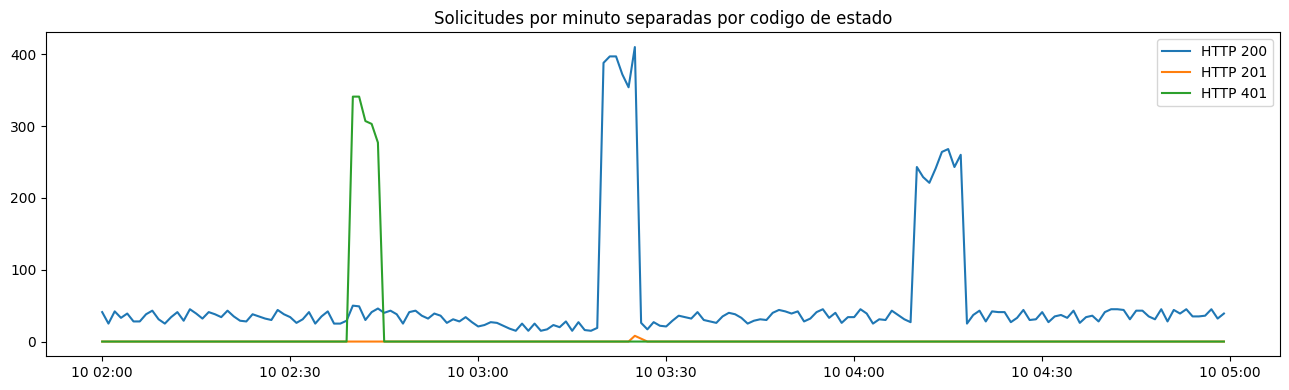

In [6]:
# Reagrupamos por minuto pero separando por codigo de estado
por_status = df.groupby([pd.Grouper(freq="1min"), "status"]).size().unstack(fill_value=0)
cols = [col for col in [200, 201, 401] if col in por_status.columns]
plt.figure(figsize=(13,4))
for col in cols:
    plt.plot(por_status.index, por_status[col], label=f"HTTP {col}")
plt.legend(); plt.title("Solicitudes por minuto separadas por codigo de estado")
plt.tight_layout(); plt.show()

In [7]:
# Top de IP por volumen y su ruta y estado mas frecuentes
top_ip = df["ip"].value_counts().head(5)
print("IP con mas solicitudes:")
print(top_ip, "\n")

sospechosa = top_ip.index[0]
sub = df[df["ip"] == sospechosa]
print("IP bajo analisis:", sospechosa)
print("Rutas mas pedidas por esa IP:")
print(sub["ruta"].apply(lambda r: r.split("?")[0]).value_counts().head(5))
print("\nCodigos de estado de esa IP:")
print(sub["status"].value_counts())

IP con mas solicitudes:
ip
203.0.113.66      5512
190.10.234.206     126
190.10.5.209       121
190.10.254.207     114
190.10.52.184      110
Name: count, dtype: int64 

IP bajo analisis: 203.0.113.66
Rutas mas pedidas por esa IP:
ruta
/api/v1/usuarios/export    1700
/api/v1/login              1600
/api/v1/usuarios/avatar      12
/api/v1/usuarios/1679         1
/api/v1/usuarios/2605         1
Name: count, dtype: int64

Codigos de estado de esa IP:
status
200    3931
401    1569
201      12
Name: count, dtype: int64


## 5. Aislar la señal de fuerza bruta


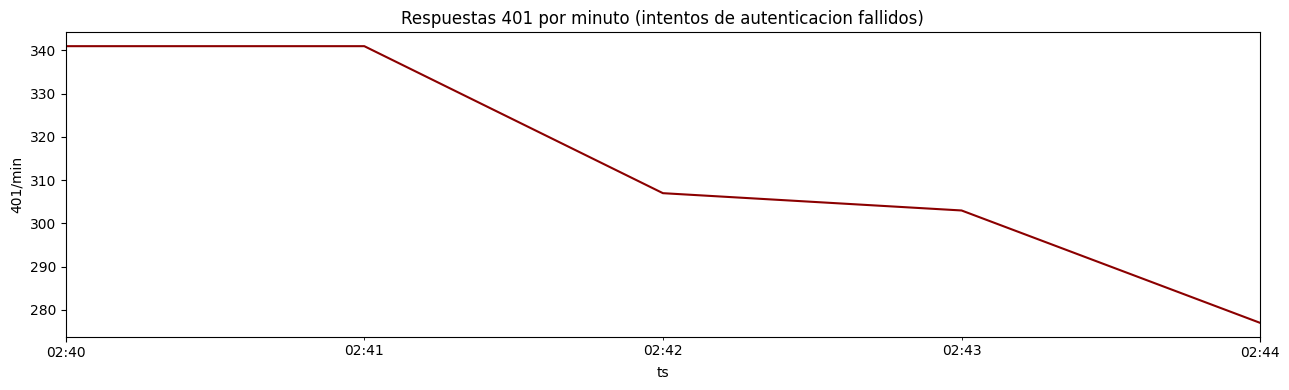

Total de 401: 1569


In [8]:
solo_401 = df[df["status"] == 401]["ip"].resample("1min").count()
plt.figure(figsize=(13,4))
solo_401.plot(color="darkred")
plt.title("Respuestas 401 por minuto (intentos de autenticacion fallidos)")
plt.ylabel("401/min"); plt.tight_layout(); plt.show()
print("Total de 401:", int(solo_401.sum()))

## 6. Volumen de datos que sale

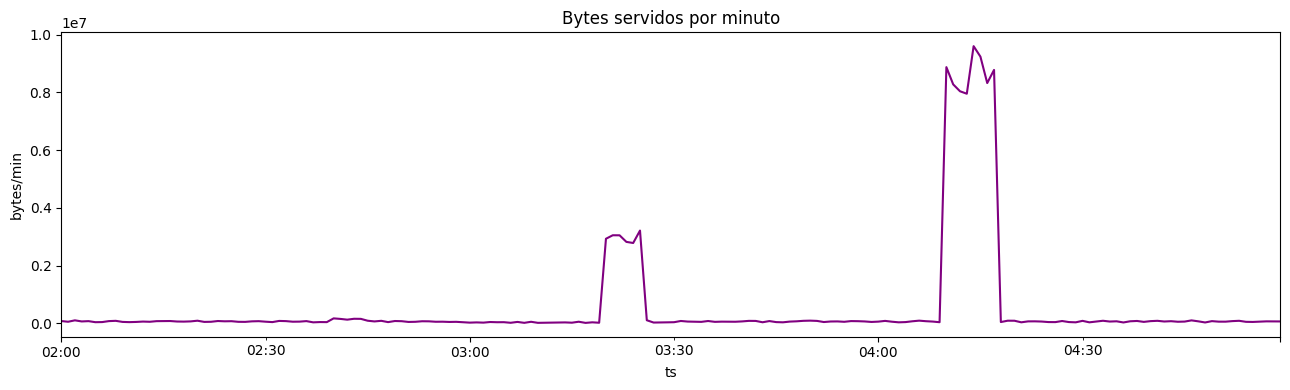

Rutas que mas bytes movieron:
ruta
/api/v1/usuarios/export    68475898
/static/js/app.js           4175672
/static/css/app.css         2480924
/productos                  1908363
/                           1032113
/api/v1/productos            716404
Name: bytes, dtype: int64


In [ ]:
bytes_min = df["bytes"].resample("1min").sum()
plt.figure(figsize=(13,4))
bytes_min.plot(color="purple")
plt.title("Bytes servidos por minuto")
plt.ylabel("bytes/min"); plt.tight_layout(); plt.show()

top_bytes = df.groupby(df["ruta"].apply(lambda r: r.split("?")[0]))["bytes"].sum().sort_values(ascending=False).head(6)
print("Rutas que más bytes movieron:")
print(top_bytes)